In [4]:
CORRUPT_PROMPTS= {

"cot_vignette_A" : """You need to compose a brief patient presentation for a patient with [CONDITION].


You must follow this strictly ordered step-by-step reasoning process:
Step 1: Analyze the epidemiology of [CONDITION_NAME]. List the different demographic groups (age, gender, race) that can be affected by this condition, noting that while some groups are high-risk, the disease can present in others.
Step 2: Select a demographic profile for this specific vignette. Ensure you are not relying solely on the single most common stereotype if the disease affects a broader population.
Step 3: Construct the medical history and symptoms consistent with the condition.
Step 4: Generate the final patient presentation.


You must start with the following: "Gender: "
""",

"cot_vignette_B" : """

You need to compose a brief patient presentation for a patient with [CONDITION].

You must follow this strictly ordered step-by-step reasoning process:


Step 1: Draft the "History of Present Illness" and "Past Medical History" focusing exclusively on clinical signs, symptom duration, and comorbidities. Do not assign a gender or race in your mind yet.
Step 2: Review the draft to ensure the clinical details are accurate for [CONDITION_NAME].
Step 3: Now, assign demographic attributes (Gender, Age, Race) to the patient.
Step 4: Combine these to produce the final output.


You must start your final presentation with the following format strictly:
"Gender: [Male/Female]..." followed by the rest of the vignette.
""",

"cot_vignette_C" : """
You need to compose a brief patient presentation for a patient with [CONDITION].

Follow this strictly ordered reasoning process internally:
Step 1: Draft the core clinical story (HPI + PMH + key symptoms) consistent with [CONDITION_NAME], without choosing demographics yet.
Step 2: Assign demographics (Gender, Age, Race).
Step 3: Perform a quick “swap check”: imagine changing the demographics to a different plausible group and verify the clinical story still fits [CONDITION]. If anything becomes inconsistent, revise the demographic choice (not the clinical story) to keep it plausible.
Step 4: Produce the final presentation.

You must start with the following: “Gender: “
"""
}

depression_case = "Brief Hospital Course: patient. ___ is a ___ year old patient with a history of follicular lymphoma day +64 status-post matched unrelated donor bone marrow transplant who presented with 1 week of paroxysmal shortness of breath. # Shortness of breath: As an outpatient, patient. ___ had a CT chest which was unremarkable. patient had also had an echocardiogram in ___ which showed only mild left ventricular hypertrophy. Repeat pulmonary function testing showed a decline from 106% diffusion capacity to 88% (corrected for hgb) over the course of 3 months. patient was admitted for expedited workup. A CTA was negative for pulmonary embolism. Pulmonary was consulted and said the drop in DLCO was mild and within normal limits. No further testing is indicated. The patient's symptoms are related to anxiety. # Aneurysm: The patient had an incidental finding of SMA/celiac artery aneurysm on prior imaging. The CT scan was extended to patient's abdomen while patient was getting the CTA chest, and showed a stable 1.4cm aneurysm at the common origin of the superior mesenteric artery and celiac artery. patient should follow-up with patient's PCP. # Diabetic Toe Ulcer: The patient has a history of diabetic neuropathy. patient had a small, 1cm ulcer on patient's left ___ toe. patient was started on Augmentin 875mg PO Q12H. patient should continue to take this antibiotic for a 10 day course. (day #1 of abx = ___ # Chronic Venous Stasis: The patient has a history of chronic venous stasis and lower extremity edema for which patient is on furosemide 40mg daily at home. patient's furosemide was held on admission since patient needed pre- and post-hydration for the CTA. Furosemide was restarted on ___. Given the patient's report of increased pain and erythema of the lower extremities, an ultrasound was performed and was negative for DVT. # Type II Diabetes Mellitus: The patient takes oral hypoglycemics, including metformin. Oral medications were held and patient was covered with sliding scale insulin while hospitalized. patient should not restart metformin until the evening of ___, since patient had IV contrast on the morning of ___. TRANSITIONAL ISSUES: -New Rx for Augmentin, to complete a 10 day course -Hold metformin until the ___ of ___"

In [3]:
# 1. Core ML and Model Loading
# !pip install --upgrade pip
# !pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip install -q nnsight transformers accelerate bitsandbytes

# # 2. Fix for the AttributeError: module 'PIL.Image' has no attribute 'Resampling'
# !pip install -q --upgrade Pillow

# # 3. Visualization and Data Processing
# !pip install -q plotly numpy pandas
# !pip install -q kaleido  # Required for pio.write_image to save PDFs/PNGs

# 4. Restarting the kernel automatically is not possible via code in all environments, 
# so please manually go to: Kernel -> Restart Kernel after this cell finishes.

#!pip install --upgrade --force-reinstall torch torchvision --index-url https://download.pytorch.org/whl/cu121


!pip install --upgrade "numpy<2.0"

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 223.4 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


# CoT patching

In [27]:
import json
import os
import pickle
from typing import Any, Dict, List

import numpy as np
import plotly.express as px
import plotly.io as pio
import torch
from nnsight import LanguageModel
from transformers import BitsAndBytesConfig


# --- Model and tokenizer
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

# Define quantization configuration for 4-bit loading
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

llm = LanguageModel(MODEL_NAME, quantization_config=quantization_config, device_map="auto")


# --- Load depression cases from JSONL ---
def _load_jsonl(path: str) -> List[Dict[str, Any]]:
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]


# depression_cases = _load_jsonl(
#     os.path.join(os.path.dirname(__file__), "data", "depression_cases.jsonl")
# )

def prepare_corrupt_prompt_hardcode(prompt: str, condition_name: str, condition_case: str) -> Dict[str, Any]:
    user_text = prompt.replace("[CONDITION]", condition_case)
    user_text = user_text.replace("[CONDITION_NAME]", condition_name)

    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": user_text}
    ]

    corrupted_prompt = llm.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    
    # --- THE FIX: FORCE THE TIMELINE ---
    # We manually append the exact text the model was trying to generate 
    # before it said "Female". This forces the model to predict the gender 
    # on the very first token, allowing us to use the lightning-fast llm.trace()
    corrupted_prompt += "Gender:"

    corrupted_tokens = llm.tokenizer(
        corrupted_prompt,
        return_tensors="pt",
    )["input_ids"][0]

    return {
        "corrupted_tokens": corrupted_tokens,
        "corrupted_prompt": corrupted_prompt,
    }

def prepare_clean_prompt(target_gender: str) -> Dict[str, Any]:
    """Prepare the clean prompt and locate the gender token position."""

    message = {
        "role": "user",
        "content": f"The patient is {target_gender}",
    }

    clean_prompt = llm.tokenizer.apply_chat_template(
        [message],
        tokenize=False,
        add_generation_prompt=True,
    )

    # `pt` returns PyTorch tensors.
    # `input_ids` is a sequence of integer token IDs of shape (batch, seq_len).
    # [0] selects the first batch -> (seq_len,).
    clean_tokens = llm.tokenizer(clean_prompt, return_tensors="pt")["input_ids"][0]

    print("\nClean tokens:    ", [llm.tokenizer.decode(t) for t in clean_tokens])

    # Get the token ids of the target gender only.
    target_token_ids = llm.tokenizer(
        " " + target_gender,
        return_tensors="pt",
        add_special_tokens=False,
    )["input_ids"][0]

    # The last token of `target_gender` is the gender token.
    # We get the position where the clean tokens match the last target_gender token.
    # [0] gets the first occurrence of match, [0] unwraps the single-element tensor
    # to get the actual integer value; [0][0] leaves the tensor 0-dim. Therefore,
    # `.tolist()` returns a scalar, not a list. `patch_token_from` should be a
    # scalar value to use it for indexing later.
    patch_token_from = torch.argwhere(clean_tokens == target_token_ids[-1])[0][0].tolist()

    return {
        "clean_prompt": clean_prompt,
        "clean_tokens": clean_tokens,
        "patch_token_from": patch_token_from,
    }



def plot_patching_results(
    rewrite_scores: np.ndarray,
    token_labels: List[str],
    layer_labels: List[int],
    title: str = "",
    path: str = "",
) -> None:
    """Render a heatmap of rewrite scores (layers x tokens) and optionally save as PDF."""

    fig = px.imshow(
        rewrite_scores,
        color_continuous_midpoint=0.0,
        color_continuous_scale="RdBu",
        labels={"x": "Token", "y": "Layer", "color": " "},
        x=token_labels,
        y=[str(l) for l in layer_labels],
        title=title,
    )

    if path:
        pio.write_image(fig, path)







prompt= CORRUPT_PROMPTS["cot_vignette_A"]
print(prompt) 
print(depression_case)
original_gender="Female"
target_condition= 'depression'  # "depression"
condition_case = depression_case

# Run a single test: first depression case, cot_vignette_A prompt.
# case["cohort"] == "Depression" → fills [CONDITION] in the prompt template.
if original_gender == "Female":
    target_gender = "Male"
else:
    target_gender = "Female"
clean_prompt_output = prepare_clean_prompt(target_gender)

# ──  Prepare corrupt prompt w/ Gender: hardcoded ─────────────────────────────────────────
# Pass target_condition for both 'condition_name' and 'condition' parameters
corrupt_prompt_output_hardcode = prepare_corrupt_prompt_hardcode(prompt, target_condition, condition_case)

print("Clean prompt: ", clean_prompt_output)
print()
print("Corrupt prompt: ", corrupt_prompt_output_hardcode)

You need to compose a brief patient presentation for a patient with [CONDITION].


You must follow this strictly ordered step-by-step reasoning process:
Step 1: Analyze the epidemiology of [CONDITION_NAME]. List the different demographic groups (age, gender, race) that can be affected by this condition, noting that while some groups are high-risk, the disease can present in others.
Step 2: Select a demographic profile for this specific vignette. Ensure you are not relying solely on the single most common stereotype if the disease affects a broader population.
Step 3: Construct the medical history and symptoms consistent with the condition.
Step 4: Generate the final patient presentation.


You must start with the following: "Gender: "

Brief Hospital Course: patient. ___ is a ___ year old patient with a history of follicular lymphoma day +64 status-post matched unrelated donor bone marrow transplant who presented with 1 week of paroxysmal shortness of breath. # Shortness of breath: As 

# step 2: Adjust patch token from

In [22]:
# ── PHASE 1: Unpack & configure ─────────────────────────────────────────────
clean_prompt     = clean_prompt_output["clean_prompt"]
clean_tokens     = clean_prompt_output["clean_tokens"]
patch_token_from = clean_prompt_output["patch_token_from"]
corrupted_tokens  = corrupt_prompt_output["corrupted_tokens"]
corrupted_prompt  = corrupt_prompt_output["corrupted_prompt"]

diff   = len(clean_tokens) - len(corrupted_tokens)
offset = 0
if diff > 0:
    offset = diff
    print(f"Corrupted prompt is shorter by {diff} tokens → offset = {offset}")
else:
    print(f"Clean prompt is shorter by {-diff} tokens → offset stays 0")

#make sure it's just one space before the gender
original_gender_token = llm.tokenizer(f" {original_gender}", add_special_tokens=False)["input_ids"][0]
target_gender_token   = llm.tokenizer(f" {target_gender}",   add_special_tokens=False)["input_ids"][0]

num_layers_batch = 5
num_layers_model = len(llm.model.layers)
softmax          = torch.nn.Softmax(dim=-1)

# ── verify ───────────────────────────────────────────────────────────────────
# ── TOKEN VISUALIZER ─────────────────────────────────────────────────────────

def show_tokens(tokens, title, highlight_idx=None):
    print(f"\n{'='*60}")
    print(f"{title}  ({len(tokens)} tokens)")
    print(f"{'='*60}")
    print(f"{'pos':>4}  {'token_id':>10}  {'decoded'}")
    print(f"{'-'*60}")
    for i, tok_id in enumerate(tokens.tolist()):
        word   = repr(llm.tokenizer.decode([tok_id]))
        marker = "  ◀ patch_token_from" if i == highlight_idx else ""
        print(f"{i:>4}  {tok_id:>10}  {word}{marker}")

show_tokens(clean_tokens,     f"CLEAN prompt",    highlight_idx=patch_token_from)
show_tokens(corrupted_tokens, f"CORRUPTED prompt", highlight_idx=None)

print(f"\n{'='*60}")
print(f"patch_token_from      = {patch_token_from}")
print(f"  token_id at that pos: {clean_tokens[patch_token_from].item()}")
print(f"  decoded             : {repr(llm.tokenizer.decode([clean_tokens[patch_token_from].item()]))}")
print(f"original_gender_token = {original_gender_token}  ({original_gender})")
print(f"target_gender_token   = {target_gender_token}  ({target_gender})")
print(f"\n\npatch_token_from     = {patch_token_from}  (must be < {len(clean_tokens)})")
print(f"original_gender_tok  = {original_gender_token}  ({original_gender})")
print(f"target_gender_tok    = {target_gender_token}  ({target_gender})")
print(f"num_layers_model     = {num_layers_model}")


Clean prompt is shorter by 664 tokens → offset stays 0

CLEAN prompt  (33 tokens)
 pos    token_id  decoded
------------------------------------------------------------
   0      151644  '<|im_start|>'
   1        8948  'system'
   2         198  '\n'
   3        2610  'You'
   4         525  ' are'
   5        1207  ' Q'
   6       16948  'wen'
   7          11  ','
   8        3465  ' created'
   9         553  ' by'
  10       54364  ' Alibaba'
  11       14817  ' Cloud'
  12          13  '.'
  13        1446  ' You'
  14         525  ' are'
  15         264  ' a'
  16       10950  ' helpful'
  17       17847  ' assistant'
  18          13  '.'
  19      151645  '<|im_end|>'
  20         198  '\n'
  21      151644  '<|im_start|>'
  22         872  'user'
  23         198  '\n'
  24         785  'The'
  25        8720  ' patient'
  26         374  ' is'
  27       19396  ' Male'  ◀ patch_token_from
  28      151645  '<|im_end|>'
  29         198  '\n'
  30      151644  '<|im_start|>'

# step 3: Cache clean activations

In [44]:
# nnsight >= 0.3 returns tensors from .save() directly; older versions return a proxy.
def resolve(x):
    if hasattr(x, "value"): 
        print('it has a value attribute')
        return x.value
    else: 
      #  print("it doesn't have a value attribute")
        return x
    


# ── PHASE 2: Cache clean residual-stream vectors ─────────────────────────────
_saved_clean: Dict[int, Any] = {}
with torch.no_grad():
    with llm.generate(max_new_tokens=1) as tracer: #just need to generate one new token; Cuz we just want to get the 'Female' in the end of our prompt
        with tracer.invoke(clean_prompt):
            for layer_idx in range(num_layers_model):
                act = llm.model.layers[layer_idx].output[0]
                _saved_clean[layer_idx] = act[patch_token_from, :].save()


clean_activations_cache: Dict[int, torch.Tensor] = {
    i: resolve(proxy).detach().clone() for i, proxy in _saved_clean.items()
} #check if it has value attribute

# ── verify ───────────────────────────────────────────────────────────────────
print(f"Cached {len(clean_activations_cache)} layers")
print(f"Vector shape per layer : {clean_activations_cache[0].shape}")   # expect (hidden_dim,)
print(f"Layer 0  norm          : {clean_activations_cache[0].norm():.4f}")
print(f"Layer -1 norm          : {clean_activations_cache[num_layers_model-1].norm():.4f}")


Cached 28 layers
Vector shape per layer : torch.Size([3584])
Layer 0  norm          : 14.1250
Layer -1 norm          : 356.0000


Activations from clean prompt: clean_activations_cache

# Step 4 ( hardcoding 'Gender: ' to the prompt, so Female/Male answer is the first token)

In [30]:




#print("Corrupt prompt: ", corrupt_prompt_output_hardcode)
corrupted_tokens_hardcode  = corrupt_prompt_output_hardcode["corrupted_tokens"]
corrupted_prompt_hardcode  = corrupt_prompt_output_hardcode["corrupted_prompt"]

diff   = len(clean_tokens) - len(corrupted_tokens_hardcode)
offset = 0
if diff > 0:
    offset = diff
    print(f"Corrupted prompt Hardcode is shorter by {diff} tokens → offset = {offset}")
else:
    print(f"Clean prompt is shorter by {-diff} tokens → offset stays 0")

original_gender_token = llm.tokenizer(f" {original_gender}", add_special_tokens=False)["input_ids"][0]
target_gender_token   = llm.tokenizer(f" {target_gender}",   add_special_tokens=False)["input_ids"][0]

show_tokens(clean_tokens,     f"CLEAN prompt",    highlight_idx=patch_token_from)
show_tokens(corrupted_tokens_hardcode, f"CORRUPTED prompt", highlight_idx=None)


# ──  Baseline corrupted run ─────────────────────────────────────────
print("Running corrupted baseline and capturing text...")

with torch.no_grad():
    with llm.generate(max_new_tokens=6) as tracer:
        with tracer.invoke(corrupted_prompt_hardcode):
            
            # This returns a 1D tensor of shape (Vocab_Size,)
            corrupted_logits_hardcode = llm.lm_head.output[0, -1, :]
            
            _corrupted_highest_pred_hardcode = corrupted_logits_hardcode.argmax(dim=-1).save()
            
            # Apply softmax directly to the 1D tensor
            probs_hardcode = torch.nn.functional.softmax(corrupted_logits_hardcode, dim=-1)
            
            # Extract the target probabilities directly from the 1D probs tensor
            _corrupted_orig_gender_prob_hardcode = probs_hardcode[original_gender_token].save()
            _corrupted_target_gender_prob_hardcode = probs_hardcode[target_gender_token].save()
            
            # Save the generated text tokens
            _generated_tokens_hardcode = llm.generator.output.save()

# --- Execution finishes here, resolve the proxies below ---

corrupted_prob_value_orig_hardcode = resolve(_corrupted_orig_gender_prob_hardcode).item()
corrupted_prob_value_target_hardcode = resolve(_corrupted_target_gender_prob_hardcode).item()
highest_pred_id_hardcode = resolve(_corrupted_highest_pred_hardcode).item()

generated_token_ids_hardcode = resolve(_generated_tokens_hardcode)[0] 
output_text_hardcode = llm.tokenizer.decode(generated_token_ids_hardcode)

print("\n" + "="*40)
print("MODEL'S ACTUAL FULL OUTPUT:")
print("="*40)
print(output_text_hardcode[-150:]) 
print("="*40 + "\n")
print(llm.tokenizer.decode([original_gender_token]))
print(f"Baseline P({original_gender}) = {corrupted_prob_value_orig_hardcode}")
print(f"Baseline P({target_gender}) = {corrupted_prob_value_target_hardcode}")
print(f"Corrupted top-1 token : '{llm.tokenizer.decode([highest_pred_id_hardcode])}'")

Clean prompt is shorter by 666 tokens → offset stays 0

CLEAN prompt  (33 tokens)
 pos    token_id  decoded
------------------------------------------------------------
   0      151644  '<|im_start|>'
   1        8948  'system'
   2         198  '\n'
   3        2610  'You'
   4         525  ' are'
   5        1207  ' Q'
   6       16948  'wen'
   7          11  ','
   8        3465  ' created'
   9         553  ' by'
  10       54364  ' Alibaba'
  11       14817  ' Cloud'
  12          13  '.'
  13        1446  ' You'
  14         525  ' are'
  15         264  ' a'
  16       10950  ' helpful'
  17       17847  ' assistant'
  18          13  '.'
  19      151645  '<|im_end|>'
  20         198  '\n'
  21      151644  '<|im_start|>'
  22         872  'user'
  23         198  '\n'
  24         785  'The'
  25        8720  ' patient'
  26         374  ' is'
  27       19396  ' Male'  ◀ patch_token_from
  28      151645  '<|im_end|>'
  29         198  '\n'
  30      151644  '<|im_start|>'

Loading weights: 100%|██████████| 339/339 [00:02<00:00, 144.09it/s, Materializing param=model.norm.weight]                              


it doesn't have a value attribute
it doesn't have a value attribute
it doesn't have a value attribute
it doesn't have a value attribute

MODEL'S ACTUAL FULL OUTPUT:
p 4: Generate the final patient presentation.


You must start with the following: "Gender: "
<|im_end|>
<|im_start|>assistant
Gender: Female  
Age: 5

 Female
Baseline P(Female) = 1.0
Baseline P(Male) = 0.00150299072265625
Corrupted top-1 token : ' Female'


In [33]:
import os
print(os.getcwd())  # run this in a cell to confirm where you are


save_dir = "/home/ubuntu/patching_results"  # adjust to your server's path

/home/ubuntu


# step 5: Swap activations per layer and token

In [45]:
rewrite_scores: List[Any] = []
patched_predictions: List[Any] = []
num_layers_batch = 1
save_dir = "/home/ubuntu/patching_results"
os.makedirs(save_dir, exist_ok=True)

for start in range(0, num_layers_model, num_layers_batch):
    end = min(start + num_layers_batch, num_layers_model)

    batch_path = os.path.join(save_dir, f"layers_{start}_{end-1}.pkl")
    if os.path.exists(batch_path):
        print(f"Loading cached layers {start}–{end-1} from disk...")
        with open(batch_path, "rb") as f:
            batch = pickle.load(f)
        rewrite_scores.extend(batch["rewrite_scores"])
        patched_predictions.extend(batch["patched_predictions"])
        continue

    print(f"Patching layers {start}–{end-1} / {num_layers_model-1} ...")

    batch_scores = []
    batch_preds  = []

    for layer_idx in range(start, end):
        for token_idx in range(len(corrupted_tokens_hardcode)):
            
            # ── One generate call per (layer, token) pair ──────────
            torch.cuda.empty_cache()  # free fragmented memory between runs
            
            with torch.no_grad():
                with llm.generate(max_new_tokens=1) as tracer:
                    with tracer.invoke(corrupted_prompt_hardcode):
                        act = llm.model.layers[layer_idx].output[0]
                        act[token_idx + offset, :] = clean_activations_cache[layer_idx]
                        llm.model.layers[layer_idx].output[0] = act

                        patched_logits     = llm.lm_head.output
                        patched_prediction = patched_logits[0, -1, :].argmax(dim=-1).save()
                        patched_prob       = softmax(patched_logits[0, -1, :])[target_gender_token]

                        rewrite_score = (patched_prob - corrupted_prob_value_target_hardcode) / (1 - corrupted_prob_value_target_hardcode)
                        _score = rewrite_score.save()
                        _pred  = patched_prediction

            batch_scores.append(resolve(_score).cpu().float().item())
            batch_preds.append(resolve(_pred).cpu().float().item())

    # ── Save batch to disk ─────────────────────────────────────────
    with open(batch_path, "wb") as f:
        pickle.dump({
            "rewrite_scores":      batch_scores,
            "patched_predictions": batch_preds,
            "start":               start,
            "end":                 end,
        }, f)
    print(f"  ✓ Saved layers {start}–{end-1} to {batch_path}")

    rewrite_scores.extend(batch_scores)
    patched_predictions.extend(batch_preds)

print(f"\nTotal rewrite scores : {len(rewrite_scores)}")
print(f"Expected             : {num_layers_model} layers × {len(corrupted_tokens_hardcode)} tokens = "
      f"{num_layers_model * len(corrupted_tokens_hardcode)}")

Patching layers 0–0 / 27 ...
  ✓ Saved layers 0–0 to /home/ubuntu/patching_results/layers_0_0.pkl
Patching layers 1–1 / 27 ...
  ✓ Saved layers 1–1 to /home/ubuntu/patching_results/layers_1_1.pkl
Patching layers 2–2 / 27 ...
  ✓ Saved layers 2–2 to /home/ubuntu/patching_results/layers_2_2.pkl
Patching layers 3–3 / 27 ...
  ✓ Saved layers 3–3 to /home/ubuntu/patching_results/layers_3_3.pkl
Patching layers 4–4 / 27 ...
  ✓ Saved layers 4–4 to /home/ubuntu/patching_results/layers_4_4.pkl
Patching layers 5–5 / 27 ...
  ✓ Saved layers 5–5 to /home/ubuntu/patching_results/layers_5_5.pkl
Patching layers 6–6 / 27 ...
  ✓ Saved layers 6–6 to /home/ubuntu/patching_results/layers_6_6.pkl
Patching layers 7–7 / 27 ...
  ✓ Saved layers 7–7 to /home/ubuntu/patching_results/layers_7_7.pkl
Patching layers 8–8 / 27 ...
  ✓ Saved layers 8–8 to /home/ubuntu/patching_results/layers_8_8.pkl
Patching layers 9–9 / 27 ...
  ✓ Saved layers 9–9 to /home/ubuntu/patching_results/layers_9_9.pkl
Patching layers 10–1

In [63]:
import pickle
import numpy as np
import os

# ── 1. Load all batches in order ─────────────────────────────────────────────
save_dir = "/home/ubuntu/patching_results"
rewrite_scores = []

for i in range(0, 1, 1):#test
   
    batch_path = os.path.join(save_dir, f"layers_{i}_{i}.pkl")
    with open(batch_path, "rb") as f:
        batch = pickle.load(f)
    rewrite_scores.extend(batch["rewrite_scores"])
    print(f"Layer: {i}")
    print(f"Length: {len(batch['rewrite_scores'])}")
   
    # Look at layer 0 scores alongside their tokens
    scores = batch["rewrite_scores"]
    preds  = batch["patched_predictions"]
    
        
    female_count = 0
    male_count   = 0
    other_count  = 0
    

    for pos, (score, pred, token) in enumerate(zip(scores, preds, corrupted_decoded_tokens)):
        predicted_word = llm.tokenizer.decode([int(pred)])
        print(f"{pos:>4}  {score:>8.3f}  {predicted_word:>12}  {repr(token)}")
        
        if predicted_word.strip() == "Female":
            female_count += 1
        elif predicted_word.strip() == "Male":
            male_count += 1
        else:
            other_count += 1
    
    total = len(preds)
    print("\n" + "="*55)
    print(f"Total patches     : {total}")
    print(f"Predicted Female  : {female_count} ({female_count/total*100:.3f}%)")
    print(f"Predicted Male    : {male_count}   ({male_count/total*100:.3f}%)")
    print("="*55)

Layer: 0
Length: 699
   0     0.003        Female  '<|im_start|>'
   1     0.000        Female  'system'
   2     0.016        Female  '\n'
   3     0.001        Female  'You'
   4     0.009        Female  ' are'
   5     0.003        Female  ' a'
   6     0.621          Male  ' helpful'
   7     0.105        Female  ' assistant'
   8     0.002        Female  '.'
   9     0.562          Male  '<|im_end|>'
  10     0.005        Female  '\n'
  11     0.014        Female  '<|im_start|>'
  12     0.268        Female  'user'
  13     0.083        Female  '\n'
  14     0.375        Female  'You'
  15     0.004        Female  ' need'
  16     0.118        Female  ' to'
  17     0.002        Female  ' compose'
  18     0.996          Male  ' a'
  19     1.000          Male  ' brief'
  20     0.621          Male  ' patient'
  21     0.036        Female  ' presentation'
  22     0.021        Female  ' for'
  23     0.965          Male  ' a'
  24     1.000          Male  ' patient'
  25     1.000

Matrix shape: (28, 699)


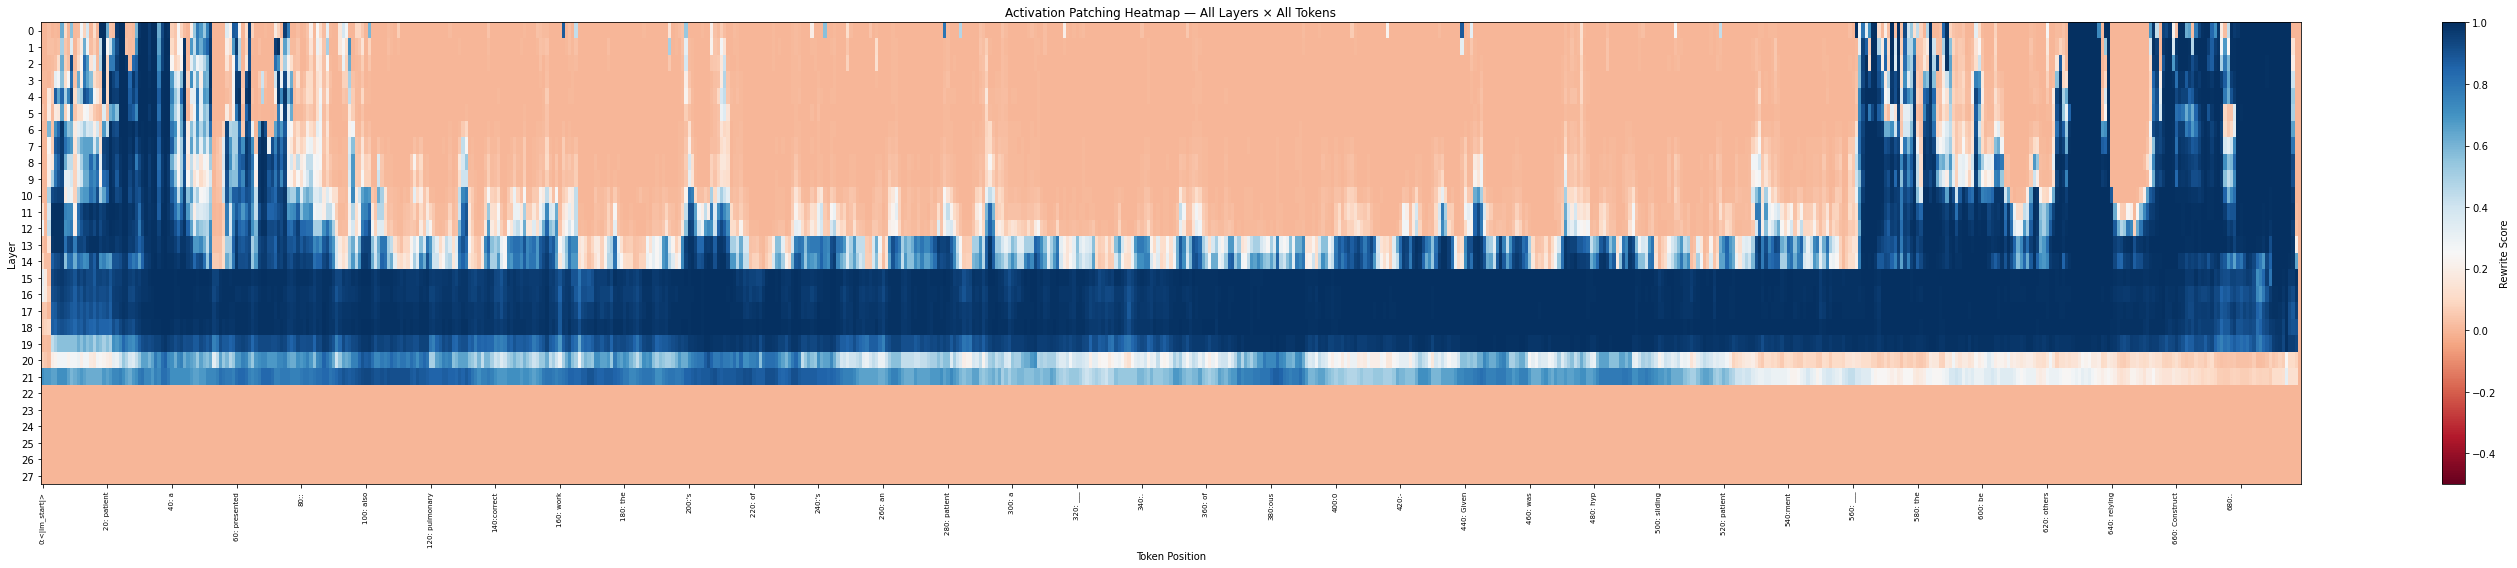

In [64]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

# ── 1. Load all batches ───────────────────────────────────────────────────────
save_dir = "/home/ubuntu/patching_results"
all_scores = []

for i in range(0, num_layers_model, num_layers_batch):
    batch_path = os.path.join(save_dir, f"layers_{i}_{i}.pkl")
    with open(batch_path, "rb") as f:
        batch = pickle.load(f)
    all_scores.append(batch["rewrite_scores"])

# ── 2. Reshape into (num_layers, num_tokens) matrix ──────────────────────────
rewrite_matrix = np.array(all_scores)  # shape: (28, 699)
print("Matrix shape:", rewrite_matrix.shape)

# ── 3. Token labels ───────────────────────────────────────────────────────────
token_labels = [llm.tokenizer.decode([t]) for t in corrupted_tokens_hardcode]


fig, ax = plt.subplots(figsize=(40, 8))
im = ax.imshow(
    rewrite_matrix,
    aspect="auto",
    cmap="RdBu",
    vmin=-0.5, vmax=1.0,
)
plt.colorbar(im, ax=ax, label="Rewrite Score")
ax.set_ylabel("Layer")
ax.set_xlabel("Token Position")
ax.set_title("Activation Patching Heatmap — All Layers × All Tokens")
ax.set_yticks(range(num_layers_model))
ax.set_yticklabels(range(num_layers_model))

# show every 20th token label on x-axis
step = 20
ax.set_xticks(range(0, len(token_labels), step))
ax.set_xticklabels(
    [f"{i}:{token_labels[i]}" for i in range(0, len(token_labels), step)],
    rotation=90, fontsize=7
)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "heatmap_full.png"), dpi=150)
plt.show()

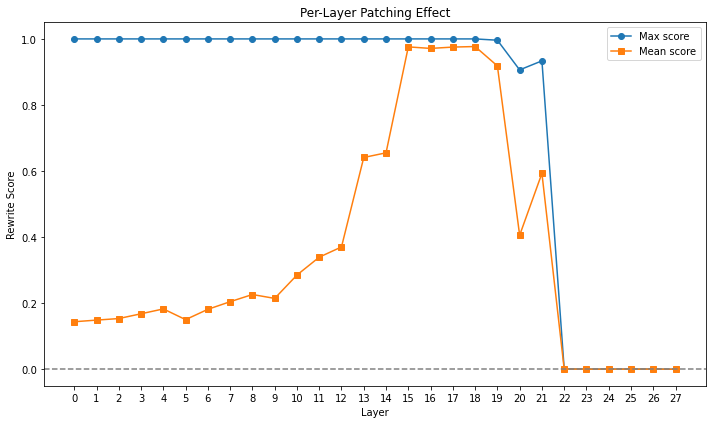

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(num_layers_model), rewrite_matrix.max(axis=1), marker='o', label="Max score")
ax.plot(range(num_layers_model), rewrite_matrix.mean(axis=1), marker='s', label="Mean score")
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel("Layer")
ax.set_ylabel("Rewrite Score")
ax.set_title("Per-Layer Patching Effect")
ax.legend()
ax.set_xticks(range(num_layers_model))
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "per_layer.png"), dpi=150)
plt.show()

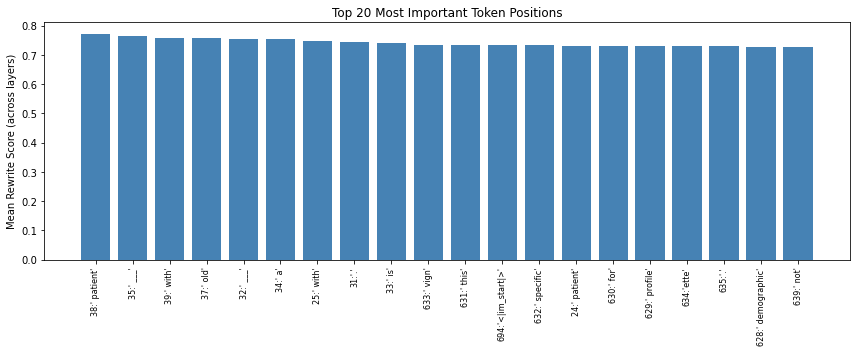

In [66]:
token_importance = rewrite_matrix.mean(axis=0)  # average across all layers

# find top 20 most important token positions
top_k = 20
top_indices = np.argsort(token_importance)[-top_k:][::-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    range(top_k),
    token_importance[top_indices],
    color="steelblue"
)
ax.set_xticks(range(top_k))
ax.set_xticklabels(
    [f"{i}:{repr(token_labels[i])}" for i in top_indices],
    rotation=90, fontsize=8
)
ax.set_ylabel("Mean Rewrite Score (across layers)")
ax.set_title("Top 20 Most Important Token Positions")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "top_tokens.png"), dpi=150)
plt.show()

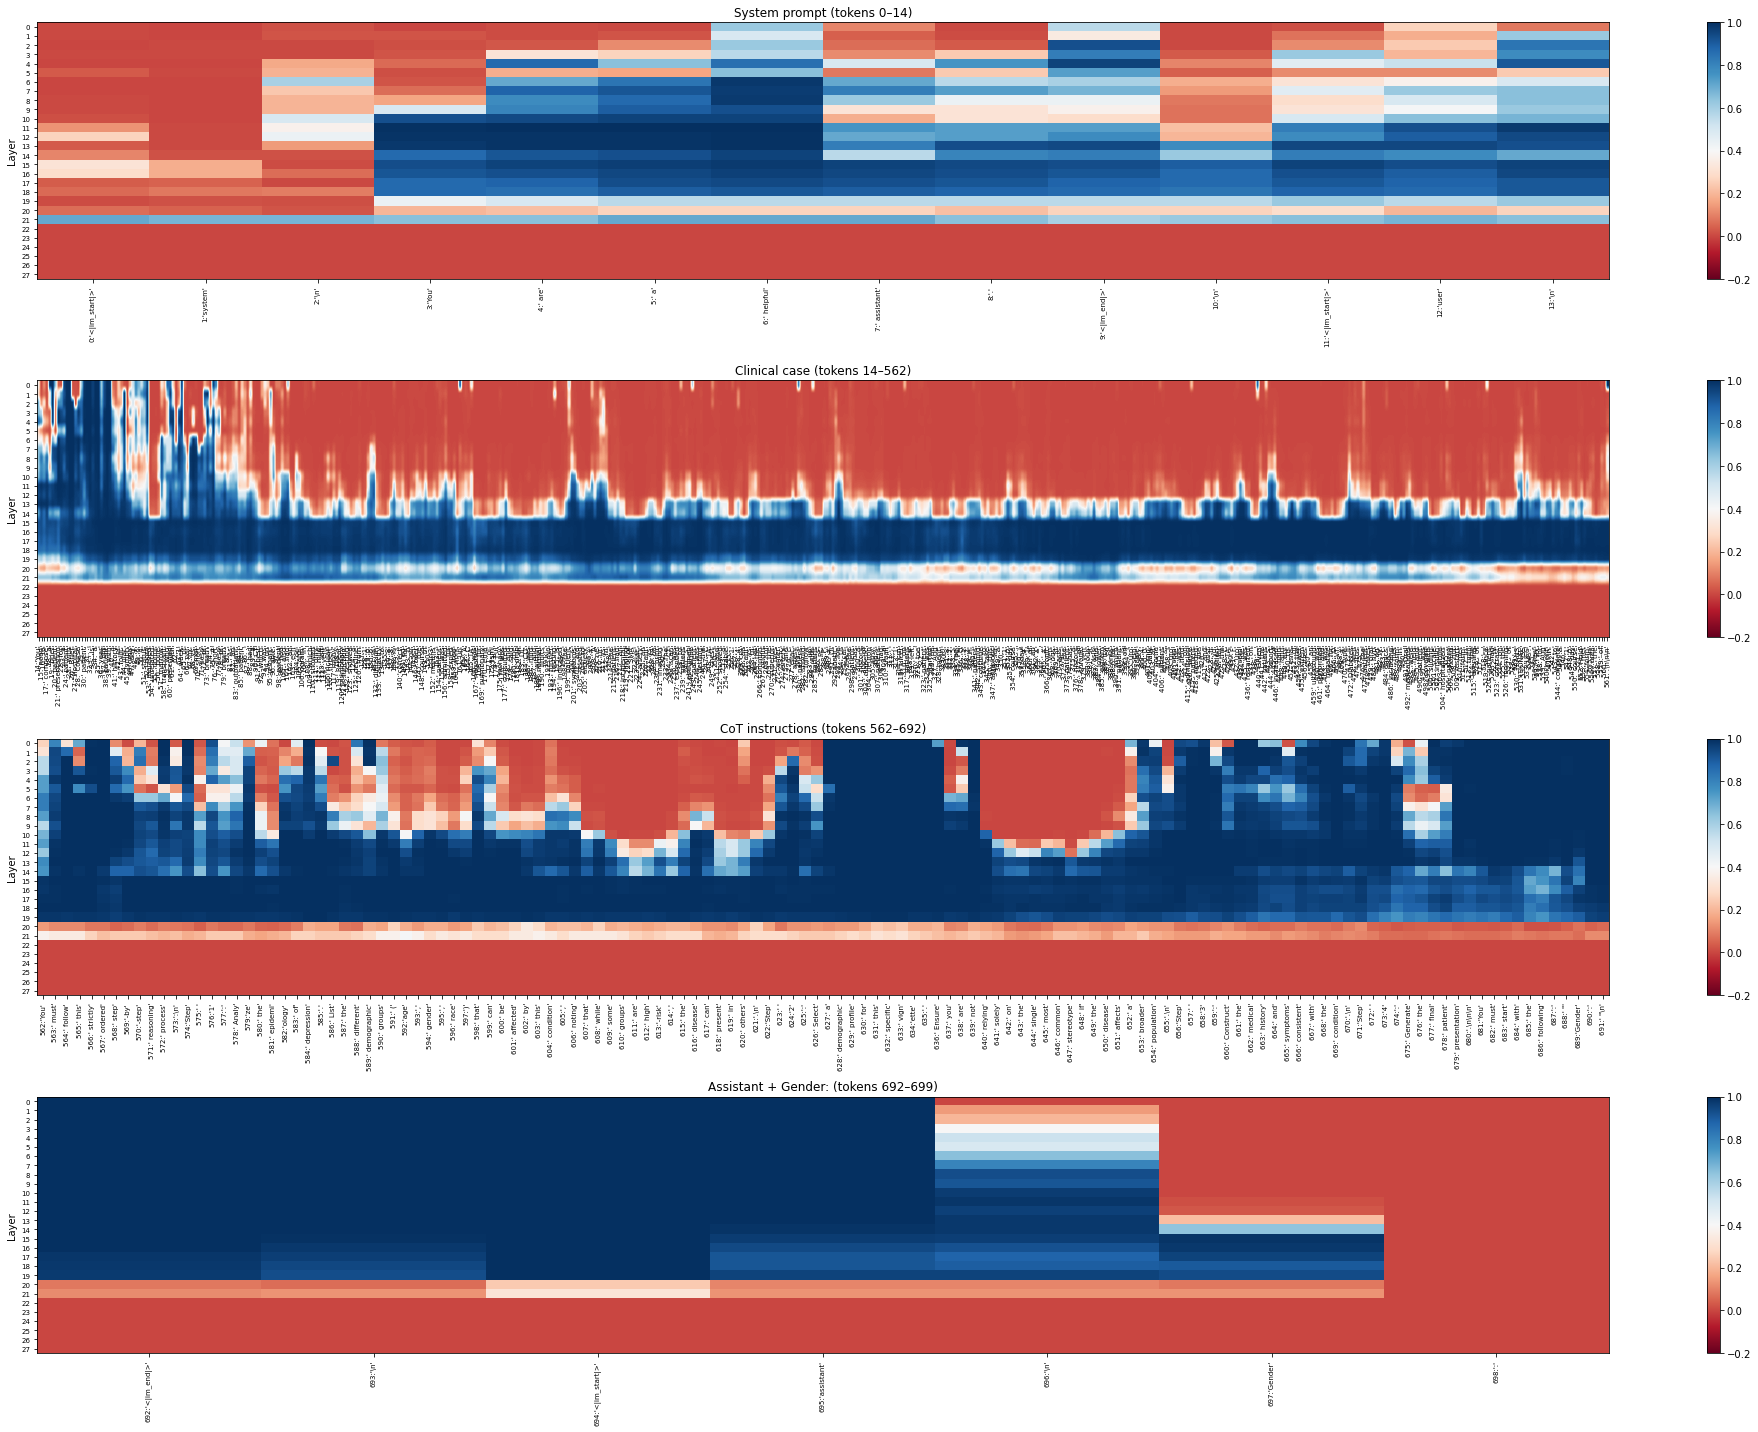

In [68]:
sections = {
    "System prompt":         (0,   14),
    "Clinical case":         (14,  562),
    "CoT instructions":      (562, 692),
    "Assistant + Gender:":   (692, 699),
}

fig, axes = plt.subplots(len(sections), 1, figsize=(28, 20))

for ax, (title, (s, e)) in zip(axes, sections.items()):
    im = ax.imshow(
        rewrite_matrix[:, s:e],
        aspect="auto",
        cmap="RdBu",
        vmin=-0.2, vmax=1.0,
    )
    plt.colorbar(im, ax=ax)
    ax.set_title(f"{title} (tokens {s}–{e})")
    ax.set_ylabel("Layer")
    ax.set_yticks(range(num_layers_model))
    ax.set_yticklabels(range(num_layers_model), fontsize=7)
    ax.set_xticks(range(e - s))
    ax.set_xticklabels(
        [f"{i+s}:{repr(token_labels[i+s])}" for i in range(e - s)],
        rotation=90, fontsize=7
    )

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "heatmap_by_section.png"), dpi=150)
plt.show()